In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

In [54]:
# filename = r'Z:\Members\Mia-Sanjana-Hadent\Processed Data\FOR SANJANA Testing_Mouse1\combined_matrix_final_total1.csv'
filename = r'Z:\Members\Mia-Sanjana-Hadent\Processed Data\042025_2mp\combined_matrix.csv'
combined_matrix = pd.read_csv( filename , index_col=0 )

In [55]:
combined_matrix

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,...,Feature23,Feature24,Feature25,Feature26,Feature27,Feature28,Feature29,Feature30,Timestamp,Cluster
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.016667,0.983333,0.000000,...,0.116667,0.150000,0.366667,0.366667,0.000000,0.000000,0.000000,1.000000,379.3972,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.033333,0.966667,...,0.066667,0.066667,0.316667,0.300000,0.250000,0.000000,0.016667,0.983333,379.6969,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,...,0.000000,0.233333,0.350000,0.283333,0.066667,0.066667,0.000000,1.000000,379.9966,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,...,0.000000,0.100000,0.400000,0.350000,0.150000,0.000000,0.000000,1.000000,380.2964,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,...,0.066667,0.133333,0.266667,0.416667,0.100000,0.016667,0.000000,1.000000,380.5962,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.483333,0.516667,0.000000,0.000000,0.816667,0.183333,42243.7645,96
121063,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.583333,0.416667,0.000000,0.000000,1.000000,0.000000,42244.1195,91
121064,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.633333,0.366667,0.000000,0.000000,0.850000,0.150000,42244.4695,96
121065,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.283333,0.716667,...,0.000000,0.000000,0.550000,0.450000,0.000000,0.000000,0.633333,0.366667,42244.8145,79


In [56]:
feature_cols = [col for col in combined_matrix.columns if col.startswith("Feature")]

cluster_means = (
    combined_matrix.groupby("Cluster")[feature_cols]
      .mean()
      .reset_index()
)

In [57]:
cluster_means

,Cluster,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,...,Feature21,Feature22,Feature23,Feature24,Feature25,Feature26,Feature27,Feature28,Feature29,Feature30
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.009007,0.035213,0.874858,...,0.005248,0.000957,0.103794,0.170780,0.354894,0.286773,0.065035,0.018723,0.005035,0.994965
1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.057668,...,0.000000,0.000000,0.009048,0.088596,0.397832,0.418579,0.076079,0.009866,0.008811,0.991189
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.014348,...,0.000580,0.000118,0.024807,0.135643,0.539071,0.274395,0.023185,0.002898,0.006435,0.993565
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.003463,0.161528,...,0.142761,0.018164,0.016488,0.053441,0.191935,0.358155,0.241600,0.138382,0.007350,0.992650
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.038784,...,0.000037,0.000000,0.002589,0.018486,0.274919,0.570268,0.117899,0.015838,0.012339,0.987661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,93,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000347,0.031733,...,0.025440,0.000000,0.000053,0.000853,0.527040,0.468053,0.003067,0.000933,0.414587,0.585413
93,94,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.037807,0.736724,...,0.225325,0.004401,0.001227,0.005051,0.474747,0.510029,0.007720,0.001227,0.295094,0.704906
94,95,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.004158,...,0.025308,0.000411,0.000804,0.006143,0.513056,0.470927,0.007888,0.001181,0.233710,0.766290
95,96,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000205,0.595401,0.404189,0.000205,0.000000,0.859080,0.140920


In [58]:
# bins

# 1-11
# 12-22
# 23-28
# 29-30

In [59]:
df = cluster_means

In [60]:
# option 1

# Suppose your feature dataframe is called df, with columns Feature_1 ... Feature_30
feature_cols = [col for col in df.columns if col.startswith("Feature")]
totalMatrix = df[feature_cols].to_numpy()  # shape: (N, 30)

# Define bin (histogram) boundaries (Python uses 0-based indices)
bins = [(0, 11), (11, 22), (22, 28), (28, 30)]

# Initialize similarity matrix
N = totalMatrix.shape[0]
Dsim = np.zeros((N, N))

# Compute pairwise histogram intersection similarity
for i in range(N):
    # Get one sample
    vec_i = totalMatrix[i, :]
    
    # Compare it to all samples at once (vectorized)
    total_diff = np.zeros(N)
    
    for (start, end) in bins:
        # Compute overlap (sum of elementwise minima) for this bin
        overlap = np.sum(np.minimum(vec_i[start:end], totalMatrix[:, start:end]), axis=1)
        
        # Histogram intersection distance term (same as MATLAB logic)
        total_diff += (1 - overlap) ** 2

    # MATLAB code then does: Dsim(:,i) = -((Dsim(:,i)).^2)
    Dsim[:, i] = -(total_diff ** 2)

Dsim = np.maximum(Dsim, Dsim.T)

# Wrap back into a DataFrame for readability
similarity_df = pd.DataFrame(Dsim, index=df.index, columns=df.index)

# print(similarity_df.head())


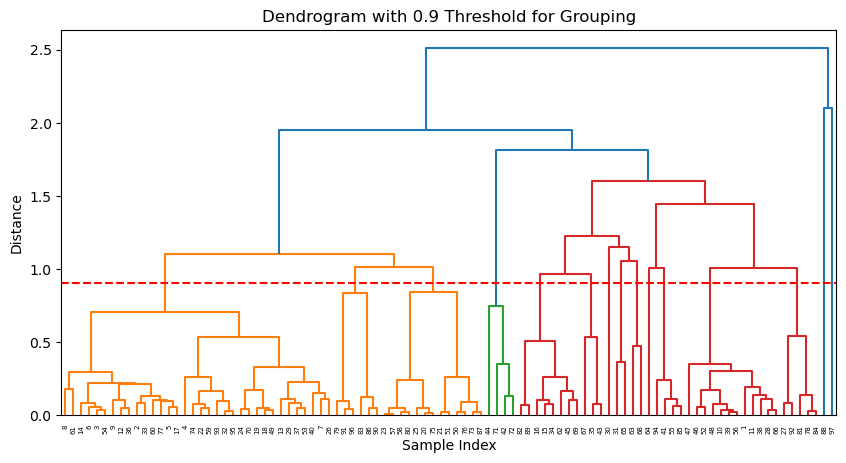

In [69]:
feature_cols = [col for col in df.columns if col.startswith("Feature")]
totalMatrix = df[feature_cols].to_numpy()  # shape: (N, 30)

bins = [(0, 11), (11, 22), (22, 28), (28, 30)]
N = totalMatrix.shape[0]
Dsim = np.zeros((N, N))

for i in range(N):
    vec_i = totalMatrix[i, :]
    total_diff = np.zeros(N)

    for (start, end) in bins:
        overlap = np.sum(np.minimum(vec_i[start:end], totalMatrix[:, start:end]), axis=1)
        total_diff += (1 - overlap) ** 2

    Dsim[:, i] = -(total_diff ** 2)

# Symmetrize
Dsim = np.maximum(Dsim, Dsim.T)

# --- convert similarity → distance ---
D = np.sqrt(np.maximum(-Dsim, 0))
np.fill_diagonal(D, 0)

# --- hierarchical clustering ---
D_condensed = squareform(D, checks=False)
Z = linkage(D_condensed, method='average')

# --- dendrogram ---
plt.figure(figsize=(10, 5))
# dendrogram(Z, labels=df.index.astype(str), leaf_rotation=90)
dendrogram(Z, labels=(df.index + 1).astype(str), leaf_rotation=90)

threshold = 0.9 
plt.axhline(y=threshold, color='r', linestyle='--', label=f"Threshold = {threshold}")

plt.title("Dendrogram with 0.9 Threshold for Grouping")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()


In [62]:
# Figures out which clusters should be grouped together based on a given threshold

def find_cluster_groups( linkage_matrix , sim_matrix , threshold):
    cluster_labels = fcluster(linkage_matrix, threshold, criterion='distance')
    cluster_groups_df = pd.DataFrame({'Cluster': sim_matrix.index - 1, 'Group': cluster_labels})
    cluster_groups_df['Cluster'] = cluster_groups_df['Cluster'] + 1
    clusters_groups_sorted = cluster_groups_df.sort_values(by='Group')
    return clusters_groups_sorted

In [63]:
# clusters_groups_sorted = cluster_groups_df.sort_values(by='Group')
clusters_groups_sorted = find_cluster_groups( Z , similarity_df , 0.9 )
clusters_groups_sorted

# clusters_groups_sorted.to_csv( 'cluster_groups_2lc.csv' )

,Cluster,Group
48,48,1
76,76,1
39,39,1
32,32,1
31,31,1
...,...,...
77,77,13
91,91,13
26,26,13
87,87,14


In [64]:
# OLD CODE

In [65]:
# import h5py

# filename = r'Z:\Members\Mia-Sanjana-Hadent\Processed Data\FOR SANJANA Testing_Mouse1\session_1_out_total1.mat'

# with h5py.File(filename, 'r') as file:
#     if 'Clusters' in file:
#         clusters_group = file['Clusters']
#         if 'sim' in clusters_group:
#             sim_data = clusters_group['sim'][:]
#             sim_matrix_data = pd.DataFrame(sim_data)

#         if 'idx' in clusters_group:
#             idx_data = clusters_group['idx'][:]
#             clusters_data = pd.DataFrame(idx_data).transpose()

In [66]:
# # original sim matrix code

# clusters_data = clusters_data.rename(columns={0: 'cluster'})

# clusters_data_sorted = clusters_data.sort_values(by='cluster')
# clusters_data_sorted['cluster'] = clusters_data_sorted['cluster'].astype( int )

# sorted_indices = clusters_data_sorted.index
# reordered_matrix = sim_matrix_data.loc[sorted_indices, sorted_indices]

# cluster_counts = clusters_data_sorted['cluster'].value_counts().reset_index()
# cluster_counts.columns = ['cluster', 'count']
# cluster_counts = cluster_counts.sort_values(by='cluster')

# clusters = cluster_counts['cluster']

# counts = cluster_counts['count'].values

# final_matrix = np.zeros((len(clusters), len(clusters)))

# # Compute averages for each cluster pair
# for i, cluster_i in enumerate(clusters):
#     for j, cluster_j in enumerate(clusters):
#         # Get the indices for rows and columns in the original matrix for the respective clusters
#         rows_i = clusters_data_sorted[clusters_data_sorted['cluster'] == cluster_i].index
#         rows_j = clusters_data_sorted[clusters_data_sorted['cluster'] == cluster_j].index
        
#         # Compute the average of the submatrix
#         submatrix = reordered_matrix.loc[rows_i, rows_j]
#         # submatrix = sim_matrix_data.loc[rows_i, rows_j]
#         final_matrix[i, j] = submatrix.values.mean()

# final_matrix_df = pd.DataFrame(final_matrix, index=clusters, columns=clusters)

In [67]:
# final_matrix_df

In [68]:
# # final_matrix_df

# D_cluster = np.sqrt(np.maximum(-final_matrix_df.values, 0))
# np.fill_diagonal(D_cluster, 0)

# # --- hierarchical clustering ---
# D_condensed = squareform(D_cluster, checks=False)
# Z_cluster = linkage(D_condensed, method='average')

# # --- dendrogram ---
# plt.figure(figsize=(8, 5))
# # dendrogram(Z_cluster, labels=final_matrix_df.index.astype(str), leaf_rotation=90)
# dendrogram(
#     Z_cluster,
#     labels=[int(float(x)) for x in final_matrix_df.index],
#     leaf_rotation=90
# )
# plt.title("Cluster-Level Dendrogram – MATLAB Similarity Matrix")
# plt.xlabel("Cluster")
# plt.ylabel("Distance")
# plt.show()
